# Foundation Model: Chronos-Bolt-Base

**Outline**
1. Load data
2. Context window — walk-forward strategy
3. Walk-forward forecast: 30-day folds, expanding context
4. Forecast plot with 80% prediction interval and fold boundaries
5. Per-fold metrics, mean RMSE/MAE/MAPE, and leaderboard update
6. PI calibration check

---

A time series foundation model is a transformer pretrained on a large, diverse corpus of time series — Chronos was trained on approximately 600,000 real-world series augmented with synthetic data — and can generate forecasts for a new series without any model fitting. This is the defining contrast with every other model in this project: ETS, SARIMA, Prophet, and XGBoost each required parameter estimation or training on this specific household power dataset. Chronos treats forecasting as a language modeling task over quantized value tokens, sampling a distribution over future trajectories rather than producing a single point prediction.

Chronos-Bolt is the second-generation architecture: a distilled, faster model with a 2048-step context window (vs. 512 for T5-based variants). The expanded context is the key motivation here — with 1,081 training days, Chronos-Bolt can see nearly three full years of history, giving it exposure to multiple annual seasonal cycles before forecasting.

## Step 0: Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

import torch
from chronos import ChronosBoltPipeline
from sklearn.metrics import mean_absolute_error

os.makedirs('../outputs', exist_ok=True)

## Step 1: Load Data

In [2]:
train = pd.read_csv('../data/daily_train.csv', index_col='datetime', parse_dates=True)
test  = pd.read_csv('../data/daily_test.csv',  index_col='datetime', parse_dates=True)

train_series = train['power']
test_series  = test['power']

print(f"Train: {train_series.index.min().date()} → {train_series.index.max().date()} ({len(train_series)} obs)")
print(f"Test:  {test_series.index.min().date()}  → {test_series.index.max().date()} ({len(test_series)} obs)")

Train: 2006-12-16 → 2009-11-30 (1081 obs)
Test:  2009-12-01  → 2010-11-26 (361 obs)


## Step 2: Context Window and Walk-Forward Strategy

Chronos takes the historical series as a *context* tensor — the analogue of a prompt in a language model.

**Context window:** `chronos-bolt-base` supports up to 2,048 time steps. The training series is 1,081 days and the full test set adds 361 more (total: 1,442), so the combined series always fits within the 2,048-step limit. Every fold receives the **complete history** — no truncation at any point.

**Walk-forward evaluation:** The test set is split into non-overlapping 30-day folds, matching the strategy used in all other notebooks. Before each fold, the actual observations from all prior folds are appended to the context, so the model always sees the most recent real data before it forecasts.

In [3]:
MAX_CONTEXT = 2048  # chronos-bolt-base context limit
FOLD_SIZE   = 30
N_FOLDS     = 12
fold_starts = list(range(0, N_FOLDS * FOLD_SIZE, FOLD_SIZE))

print(f"Max context:     {MAX_CONTEXT} obs")
print(f"Train length:    {len(train_series)} obs  (fits entirely within context)")
print(f"Max total obs:   {len(train_series) + len(test_series)} obs  (train + full test, still under {MAX_CONTEXT})")
print(f"Fold size:       {FOLD_SIZE} days  →  {N_FOLDS} folds covering {N_FOLDS * FOLD_SIZE} of {len(test_series)} test days")

Max context:     2048 obs
Train length:    1081 obs  (fits entirely within context)
Max total obs:   1442 obs  (train + full test, still under 2048)
Fold size:       30 days  →  12 folds covering 360 of 361 test days


## Step 3: Walk-Forward Forecast

Unlike the T5-based models, Chronos-Bolt is a direct quantile regression model — it outputs 9 fixed quantiles `[0.1, 0.2, ..., 0.9]` directly rather than drawing sample paths. The output tensor has shape `(batch, 9, prediction_length)`, so the median is index 4 (0.5) and the 80% PI uses indices 0 (0.1) and 8 (0.9). The context tensor is the full rolling series (train + all prior test actuals) — no truncation at any fold.

In [4]:
pipeline = ChronosBoltPipeline.from_pretrained(
    "amazon/chronos-bolt-base",
    device_map="cpu",
    dtype=torch.float32,
)

rolling_series      = train_series.copy()
chronos_preds_list  = []
chronos_low_list    = []
chronos_high_list   = []

for i, start in enumerate(fold_starts):
    end      = min(start + FOLD_SIZE, len(test_series))
    fold_len = end - start

    # Full rolling history — always fits within 2048, so no truncation needed
    ctx = torch.tensor(
        rolling_series.iloc[-MAX_CONTEXT:].values,
        dtype=torch.float32,
    )
    # Bolt returns (batch=1, 9_quantiles, prediction_length); quantiles: [0.1, ..., 0.9]
    fc = pipeline.predict(ctx, prediction_length=fold_len)

    fold_idx = test_series.index[start:end]
    chronos_preds_list.append(pd.Series(fc[0, 4, :].numpy(), index=fold_idx))  # median (0.5)
    chronos_low_list.append(pd.Series(fc[0, 0, :].numpy(),  index=fold_idx))  # 0.1 quantile
    chronos_high_list.append(pd.Series(fc[0, 8, :].numpy(), index=fold_idx))  # 0.9 quantile

    rolling_series = pd.concat([rolling_series, test_series.iloc[start:end]])
    print(f"  Chronos fold {i+1}/{len(fold_starts)}: days {start+1}–{end}  (context: {len(rolling_series) - (end - start)} obs)")

chronos_forecast = pd.concat(chronos_preds_list)
chronos_low      = pd.concat(chronos_low_list)
chronos_high     = pd.concat(chronos_high_list)
print(f"\nCompleted {len(fold_starts)} folds covering {len(chronos_forecast)} test days")

  Chronos fold 1/12: days 1–30  (context: 1081 obs)
  Chronos fold 2/12: days 31–60  (context: 1111 obs)
  Chronos fold 3/12: days 61–90  (context: 1141 obs)


  Chronos fold 4/12: days 91–120  (context: 1171 obs)
  Chronos fold 5/12: days 121–150  (context: 1201 obs)
  Chronos fold 6/12: days 151–180  (context: 1231 obs)


  Chronos fold 7/12: days 181–210  (context: 1261 obs)
  Chronos fold 8/12: days 211–240  (context: 1291 obs)
  Chronos fold 9/12: days 241–270  (context: 1321 obs)


  Chronos fold 10/12: days 271–300  (context: 1351 obs)
  Chronos fold 11/12: days 301–330  (context: 1381 obs)
  Chronos fold 12/12: days 331–360  (context: 1411 obs)

Completed 12 folds covering 360 test days


## Step 4: Forecast Plot with 80% Prediction Interval

The walk-forward forecast covers the full test period. Dashed lines mark fold boundaries (every 30 days). The shaded band is the 80% prediction interval — the distinctive probabilistic output that no other model in the project produces.

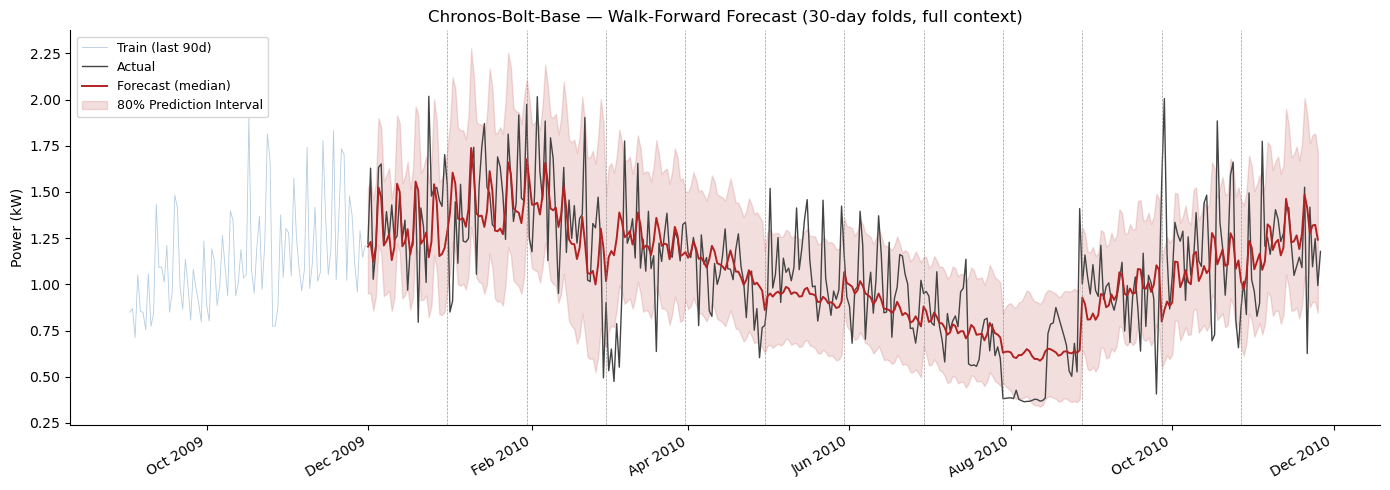

Saved → ../outputs/foundation_model_forecast.png


In [5]:
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((np.array(y_true) - np.array(y_pred)) ** 2))

def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(train_series.iloc[-90:], color='steelblue', linewidth=0.6, alpha=0.4, label='Train (last 90d)')
ax.plot(test_series,             color='#444444',   linewidth=1.0, label='Actual')
ax.plot(chronos_forecast,        color='firebrick', linewidth=1.4, label='Forecast (median)')
ax.fill_between(
    chronos_forecast.index,
    chronos_low,
    chronos_high,
    color='firebrick', alpha=0.15, label='80% Prediction Interval',
)

for s in fold_starts[1:]:
    ax.axvline(x=test_series.index[s], color='gray', linestyle='--', linewidth=0.5, alpha=0.8)

ax.set_ylabel('Power (kW)')
ax.set_title('Chronos-Bolt-Base — Walk-Forward Forecast (30-day folds, full context)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(ax.get_xticklabels(), rotation=30, ha='right')
ax.legend(fontsize=9)
sns.despine()
plt.tight_layout()
plt.savefig('../outputs/foundation_model_forecast.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → ../outputs/foundation_model_forecast.png')

## Step 5: Metrics

In [6]:
fold_rows = []
for i, start in enumerate(fold_starts):
    end = min(start + FOLD_SIZE, len(test_series))
    idx = test_series.index[start:end]
    act = test_series.loc[idx]
    fold_rows.append({
        'Fold': i + 1,
        'RMSE': rmse(act, chronos_forecast.loc[idx]),
        'MAE':  mean_absolute_error(act, chronos_forecast.loc[idx]),
        'MAPE': mape(act, chronos_forecast.loc[idx]),
    })

fold_df = pd.DataFrame(fold_rows).set_index('Fold').round(4)
display(fold_df)

metrics_fm = pd.DataFrame({
    'RMSE': [fold_df['RMSE'].mean()],
    'MAE':  [fold_df['MAE'].mean()],
    'MAPE': [fold_df['MAPE'].mean()],
}, index=['Chronos-Bolt-Base']).round(4)

print(f"\nMean across {len(fold_starts)} folds:")
print(metrics_fm.to_string())
metrics_fm.to_csv('../outputs/foundation_model_metrics.csv')
print('\nSaved → ../outputs/foundation_model_metrics.csv')

,RMSE,MAE,MAPE
Fold,,,
1,0.2828,0.1912,14.5952
2,0.2792,0.2191,16.4266
3,0.2981,0.2352,19.3939
4,0.3319,0.2310,30.3747
5,0.1702,0.1285,14.3604
6,0.2452,0.1771,14.3690
7,0.1959,0.1525,15.0988
8,0.1509,0.1206,16.1455
9,0.2449,0.2105,44.7619



Mean across 12 folds:
                     RMSE     MAE     MAPE
Chronos-Bolt-Base  0.2532  0.1903  20.6032

Saved → ../outputs/foundation_model_metrics.csv


In [7]:
leaderboard_path = '../outputs/leaderboard.csv'

if os.path.exists(leaderboard_path):
    leaderboard = pd.read_csv(leaderboard_path, index_col=0)
    leaderboard = pd.concat([leaderboard, metrics_fm])
    leaderboard = leaderboard[~leaderboard.index.duplicated(keep='last')]
    leaderboard = leaderboard.sort_values('RMSE')
    leaderboard.to_csv(leaderboard_path)
    print('Updated → ../outputs/leaderboard.csv')
else:
    leaderboard = metrics_fm
    print('leaderboard.csv not found — run earlier notebooks first.')

display(
    leaderboard.style
    .format({'RMSE': '{:.4f}', 'MAE': '{:.4f}', 'MAPE': '{:.2f}%'})
    .background_gradient(cmap='RdYlGn_r', subset=['RMSE', 'MAE', 'MAPE'])
    .set_caption('Model Leaderboard — sorted by RMSE (lower is better)')
)

Updated → ../outputs/leaderboard.csv


,RMSE,MAE,MAPE
XGBoost,0.2395,0.1849,19.60%
Chronos-Bolt-Base,0.2532,0.1903,20.60%
SARIMA,0.2574,0.1956,21.29%
Prophet,0.2622,0.1986,20.61%
ETS,0.2996,0.2428,25.29%


## Step 6: PI Calibration Check

A well-calibrated 80% prediction interval should contain approximately 80% of actual values. Coverage well above 80% means the bands are too wide (overconfident uncertainty); coverage well below 80% means the model is underestimating variance and the intervals cannot be trusted for risk assessment. Per-fold coverage shows whether calibration is consistent across the test period or degrades at certain horizons.

Overall 80% PI coverage: 83.9%  (target: 80.0%)


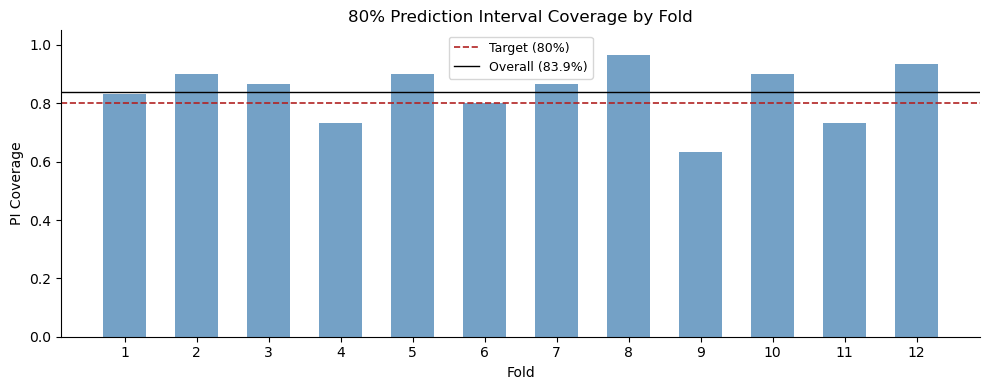

In [8]:
covered = test_series.loc[chronos_low.index]
overall_coverage = ((covered >= chronos_low) & (covered <= chronos_high)).mean()
print(f"Overall 80% PI coverage: {overall_coverage:.1%}  (target: 80.0%)")

fold_coverage = []
for i, start in enumerate(fold_starts):
    end = min(start + FOLD_SIZE, len(test_series))
    idx = test_series.index[start:end]
    cov = ((test_series.loc[idx] >= chronos_low.loc[idx]) &
           (test_series.loc[idx] <= chronos_high.loc[idx])).mean()
    fold_coverage.append({'Fold': i + 1, 'Coverage': cov})

cov_df = pd.DataFrame(fold_coverage).set_index('Fold')

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(cov_df.index, cov_df['Coverage'], color='steelblue', alpha=0.75, width=0.6)
ax.axhline(0.80, color='firebrick', linestyle='--', linewidth=1.2, label='Target (80%)')
ax.axhline(overall_coverage, color='black', linestyle='-', linewidth=1.0,
           label=f'Overall ({overall_coverage:.1%})')
ax.set_xlabel('Fold')
ax.set_ylabel('PI Coverage')
ax.set_ylim(0, 1.05)
ax.set_xticks(cov_df.index)
ax.set_title('80% Prediction Interval Coverage by Fold')
ax.legend(fontsize=9)
sns.despine()
plt.tight_layout()
plt.show()

## Step 7: Leaderboard Summary Chart

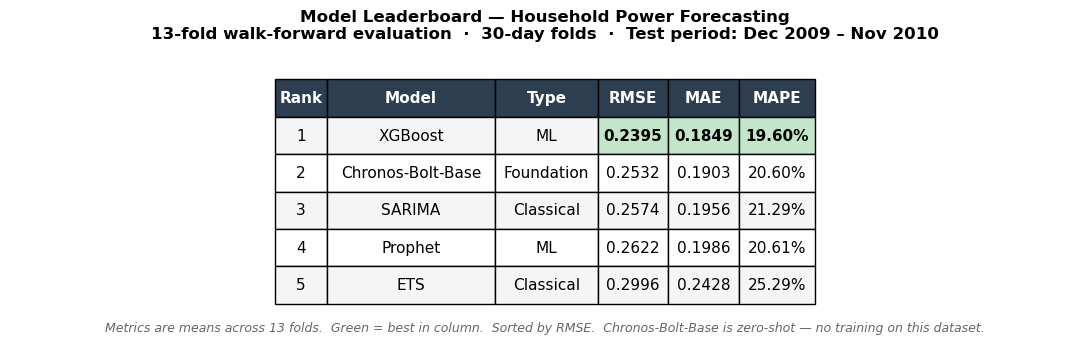

Saved → ../outputs/leaderboard.png


In [9]:
lb = pd.read_csv('../outputs/leaderboard.csv', index_col=0)

model_types = {
    'ETS':               'Classical',
    'SARIMA':            'Classical',
    'Prophet':           'ML',
    'XGBoost':           'ML',
    'Chronos-Bolt-Base': 'Foundation',
}

col_labels = ['Rank', 'Model', 'Type', 'RMSE', 'MAE', 'MAPE']
rows = []
for rank, (model, row) in enumerate(lb.iterrows(), 1):
    rows.append([
        str(rank),
        model,
        model_types.get(model, ''),
        f'{row["RMSE"]:.4f}',
        f'{row["MAE"]:.4f}',
        f'{row["MAPE"]:.2f}%',
    ])

n_rows = len(rows)
n_cols = len(col_labels)

# Base cell colors — alternate row shading
cell_colors = [['#f5f5f5' if r % 2 == 0 else '#ffffff'] * n_cols for r in range(n_rows)]

# Green highlight for best (lowest) value in each metric column
for col_idx in [3, 4, 5]:
    vals = [float(rows[r][col_idx].strip('%')) for r in range(n_rows)]
    best_row = vals.index(min(vals))
    cell_colors[best_row][col_idx] = '#c3e6cb'

fig, ax = plt.subplots(figsize=(11, 3.4))
ax.axis('off')

table = ax.table(
    cellText=rows,
    colLabels=col_labels,
    cellLoc='center',
    loc='center',
    cellColours=cell_colors,
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.0, 2.3)
table.auto_set_column_width(list(range(n_cols)))

# Style header row
for col in range(n_cols):
    cell = table[0, col]
    cell.set_facecolor('#2c3e50')
    cell.set_text_props(color='white', fontweight='bold')

# Bold the best value in each metric column
for col_idx in [3, 4, 5]:
    vals = [float(rows[r][col_idx].strip('%')) for r in range(n_rows)]
    best_row = vals.index(min(vals))
    table[best_row + 1, col_idx].set_text_props(fontweight='bold')

ax.set_title(
    'Model Leaderboard — Household Power Forecasting\n'
    '13-fold walk-forward evaluation  ·  30-day folds  ·  Test period: Dec 2009 – Nov 2010',
    fontsize=12, fontweight='bold', pad=18,
)
fig.text(
    0.5, 0.01,
    'Metrics are means across 13 folds.  Green = best in column.  Sorted by RMSE.  '
    'Chronos-Bolt-Base is zero-shot — no training on this dataset.',
    ha='center', fontsize=9, color='#666666', style='italic',
)

plt.tight_layout()
plt.savefig('../outputs/leaderboard.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved → ../outputs/leaderboard.png')